In [ ]:
# Install and set up Kaggle
!pip install -q kaggle

from google.colab import files
uploaded = files.upload()  # Upload your kaggle.json here

# Move the API key to the correct location
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
# Download the dataset
!kaggle datasets download -d abdallahalidev/plantvillage-dataset

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [02:19<00:00, 15.7MB/s]



In [ ]:
# Extract the dataset and check nested structure
import zipfile
import os

# Unzip the dataset
with zipfile.ZipFile('plantvillage-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('plantvillage_dataset')

# Check the extracted structure
print("Dataset extracted. Checking structure...")
base_path = '/content/plantvillage_dataset'
print("Base path:", base_path)
print("\nAvailable folders:")
folders = os.listdir(base_path)
print(folders)

inner_folder = os.path.join(base_path, 'plantvillage dataset')
print(f"\nInner folder: {inner_folder}")
print("Contents of inner folder:")
inner_contents = os.listdir(inner_folder)
print(inner_contents)

# Check if there's a 'color' folder
color_folder = None
segmented_folder = None

for item in inner_contents:
    item_path = os.path.join(inner_folder, item)
    if os.path.isdir(item_path):
        if 'color' in item.lower():
            color_folder = item_path
        elif 'segmented' in item.lower():
            segmented_folder = item_path

print(f"\nColor folder found: {color_folder}")
print(f"Segmented folder found: {segmented_folder}")


Dataset extracted. Checking structure...
Base path: /content/plantvillage_dataset

Available folders:
['plantvillage dataset']

Inner folder: /content/plantvillage_dataset/plantvillage dataset
Contents of inner folder:
['segmented', 'grayscale', 'color']

Color folder found: /content/plantvillage_dataset/plantvillage dataset/color
Segmented folder found: /content/plantvillage_dataset/plantvillage dataset/segmented


In [ ]:
# Set up the correct data directory
# We'll use the color images (not segmented/grayscale)
data_dir = color_folder if color_folder else inner_folder

print(f"\nUsing data directory: {data_dir}")

# List all class folders (should be 38)
import pathlib
data_dir_path = pathlib.Path(data_dir)
class_folders = [item.name for item in data_dir_path.iterdir() if item.is_dir()]
print(f"\nNumber of class folders found: {len(class_folders)}")
print("First 10 classes:")
for i, folder in enumerate(sorted(class_folders)[:10]):
    print(f"{i+1}. {folder}")

# Count total images
image_count = 0
for class_folder in class_folders:
    class_path = data_dir_path / class_folder
    images = list(class_path.glob('*.jpg')) + list(class_path.glob('*.JPG')) + list(class_path.glob('*.png'))
    image_count += len(images)
    if len(images) > 0:
        print(f"{class_folder}: {len(images)} images")

print(f"\nTotal images in dataset: {image_count}")


Using data directory: /content/plantvillage_dataset/plantvillage dataset/color

Number of class folders found: 38
First 10 classes:
1. Apple___Apple_scab
2. Apple___Black_rot
3. Apple___Cedar_apple_rust
4. Apple___healthy
5. Blueberry___healthy
6. Cherry_(including_sour)___Powdery_mildew
7. Cherry_(including_sour)___healthy
8. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
9. Corn_(maize)___Common_rust_
10. Corn_(maize)___Northern_Leaf_Blight
Corn_(maize)___Northern_Leaf_Blight: 985 images
Peach___healthy: 360 images
Tomato___Late_blight: 1908 images
Tomato___Early_blight: 1000 images
Tomato___Leaf_Mold: 952 images
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 513 images
Tomato___healthy: 1591 images
Pepper,_bell___Bacterial_spot: 997 images
Tomato___Tomato_mosaic_virus: 373 images
Tomato___Septoria_leaf_spot: 1771 images
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1076 images
Grape___healthy: 423 images
Pepper,_bell___healthy: 1478 images
Tomato___Target_Spot: 1404 images
G

In [ ]:
import os
from collections import Counter
DATA_DIR = "/content/plantvillage_dataset/plantvillage dataset/color"
class_counts = {}

for class_name in os.listdir(DATA_DIR):
    class_path = os.path.join(DATA_DIR, class_name)

    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        class_counts[class_name] = num_images
total_images = sum(class_counts.values())

print("Total classes:", len(class_counts))
print("Total images:", total_images)

print("\nSample class distribution:\n")
for cls, count in list(class_counts.items())[:10]:
    print(f"{cls}: {count}")
small_classes = [c for c, n in class_counts.items() if n < 500]
large_classes = [c for c, n in class_counts.items() if n > 3000]

print("Small classes (<500 images):", len(small_classes))
print("Large classes (>3000 images):", len(large_classes))
sorted_classes = sorted(class_counts.items(), key=lambda x: x[1])

print("\nMost underrepresented classes:")
for cls, count in sorted_classes[:5]:
    print(cls, "->", count)

print("\nMost overrepresented classes:")
for cls, count in sorted_classes[-5:]:
    print(cls, "->", count)


Total classes: 38
Total images: 54305

Sample class distribution:

Corn_(maize)___Northern_Leaf_Blight: 985
Peach___healthy: 360
Tomato___Late_blight: 1909
Tomato___Early_blight: 1000
Tomato___Leaf_Mold: 952
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 513
Tomato___healthy: 1591
Pepper,_bell___Bacterial_spot: 997
Tomato___Tomato_mosaic_virus: 373
Tomato___Septoria_leaf_spot: 1771
Small classes (<500 images): 7
Large classes (>3000 images): 3

Most underrepresented classes:
Potato___healthy -> 152
Apple___Cedar_apple_rust -> 275
Peach___healthy -> 360
Raspberry___healthy -> 371
Tomato___Tomato_mosaic_virus -> 373

Most overrepresented classes:
Tomato___Bacterial_spot -> 2127
Peach___Bacterial_spot -> 2297
Soybean___healthy -> 5090
Tomato___Tomato_Yellow_Leaf_Curl_Virus -> 5357
Orange___Haunglongbing_(Citrus_greening) -> 5507


In [ ]:
import torch
from torchvision import datasets, transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),   # DenseNet input size
    transforms.ToTensor()
])
dataset = datasets.ImageFolder(
    root="/content/plantvillage_dataset/plantvillage dataset/color",
    transform=transform
)
print("Total images loaded:", len(dataset))
print("Total classes:", len(dataset.classes))

print("\nFirst 5 classes:")
for i in range(5):
    print(i, "->", dataset.classes[i])
image, label = dataset[0]

print("Image shape:", image.shape)
print("Label index:", label)
print("Label name:", dataset.classes[label])


Total images loaded: 54305
Total classes: 38

First 5 classes:
0 -> Apple___Apple_scab
1 -> Apple___Black_rot
2 -> Apple___Cedar_apple_rust
3 -> Apple___healthy
4 -> Blueberry___healthy
Image shape: torch.Size([3, 224, 224])
Label index: 0
Label name: Apple___Apple_scab


In [ ]:
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset, [train_size, val_size]
)
train_labels = [dataset.targets[i] for i in train_dataset.indices]
class_counts = Counter(train_labels)

class_weights = {
    cls: 1.0 / count for cls, count in class_counts.items()
}
sample_weights = [class_weights[label] for label in train_labels]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    sampler=sampler
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False
)
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch labels:", labels)


Batch image shape: torch.Size([8, 3, 224, 224])
Batch labels: tensor([12, 15,  4, 12,  2, 29,  0, 27])


In [ ]:
sampled_labels = []

for _, labels in train_loader:
    sampled_labels.extend(labels.tolist())

print("Sampled training distribution (after weighting):")
print(Counter(sampled_labels))


Sampled training distribution (after weighting):
Counter({11: 1221, 21: 1198, 19: 1198, 27: 1196, 2: 1195, 3: 1189, 23: 1184, 10: 1176, 24: 1176, 26: 1171, 15: 1160, 17: 1159, 37: 1156, 7: 1155, 8: 1149, 34: 1148, 5: 1146, 16: 1146, 31: 1146, 35: 1140, 33: 1130, 12: 1129, 28: 1126, 9: 1126, 22: 1124, 13: 1123, 6: 1120, 25: 1119, 32: 1119, 20: 1116, 18: 1111, 36: 1110, 14: 1109, 0: 1104, 29: 1099, 1: 1098, 4: 1097, 30: 1075})


In [ ]:
import torch.nn as nn
from torchvision import models
model = models.densenet121(pretrained=True)
for param in model.features.parameters():
    param.requires_grad = False
num_features = model.classifier.in_features

model.classifier = nn.Linear(num_features, 38)
dummy_input = torch.randn(1, 3, 224, 224)
output = model(dummy_input)

print("Output shape:", output.shape)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 200MB/s]


Output shape: torch.Size([1, 38])


In [ ]:
import torch.nn as nn
import torch
model = model.cuda()

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=0.001
)
model.train()

for batch_idx, (images, labels) in enumerate(train_loader):

    # Move data to GPU
    images = images.cuda()
    labels = labels.cuda()

    # Clear gradients
    optimizer.zero_grad()

    # Forward pass
    outputs = model(images)

    # Loss
    loss = criterion(outputs, labels)

    # Backward pass
    loss.backward()

    # Update weights
    optimizer.step()

    # Print loss
    if batch_idx % 50 == 0:
        print(f"Batch {batch_idx}, Loss: {loss.item():.4f}")


Batch 0, Loss: 3.6039
Batch 50, Loss: 3.6922
Batch 100, Loss: 2.3306
Batch 150, Loss: 1.5020
Batch 200, Loss: 1.7446
Batch 250, Loss: 1.4963
Batch 300, Loss: 0.7833
Batch 350, Loss: 1.2554
Batch 400, Loss: 0.7706
Batch 450, Loss: 0.9498
Batch 500, Loss: 1.1744
Batch 550, Loss: 0.4207
Batch 600, Loss: 0.8395
Batch 650, Loss: 0.5793
Batch 700, Loss: 0.6171
Batch 750, Loss: 1.2702
Batch 800, Loss: 0.8136
Batch 850, Loss: 0.6851
Batch 900, Loss: 0.3340
Batch 950, Loss: 0.5728
Batch 1000, Loss: 0.5034
Batch 1050, Loss: 0.2645
Batch 1100, Loss: 0.8691
Batch 1150, Loss: 0.2686
Batch 1200, Loss: 0.2696
Batch 1250, Loss: 0.2110
Batch 1300, Loss: 0.6192
Batch 1350, Loss: 0.7277
Batch 1400, Loss: 0.2964
Batch 1450, Loss: 0.4024
Batch 1500, Loss: 0.1340
Batch 1550, Loss: 0.5563
Batch 1600, Loss: 0.2699
Batch 1650, Loss: 0.4679
Batch 1700, Loss: 0.1573
Batch 1750, Loss: 0.4638
Batch 1800, Loss: 0.2101
Batch 1850, Loss: 2.2650
Batch 1900, Loss: 0.7007
Batch 1950, Loss: 0.3653
Batch 2000, Loss: 0.141

In [ ]:
model.eval()
correct = 0
total = 0
val_loss = 0.0

with torch.no_grad():
    for images, labels in val_loader:

        images = images.cuda()
        labels = labels.cuda()

        outputs = model(images)

        loss = criterion(outputs, labels)
        val_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()
val_accuracy = 100 * correct / total
val_loss = val_loss / len(val_loader)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.2f}%")


Validation Loss: 0.1865
Validation Accuracy: 94.16%


In [ ]:
from collections import defaultdict

class_correct = defaultdict(int)
class_total = defaultdict(int)
model.eval()

with torch.no_grad():
    for images, labels in val_loader:

        images = images.cuda()
        labels = labels.cuda()

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for label, pred in zip(labels, preds):
            class_total[label.item()] += 1
            if label == pred:
                class_correct[label.item()] += 1
print("Per-class accuracy:\n")

for class_idx in class_total:
    acc = 100 * class_correct[class_idx] / class_total[class_idx]
    class_name = dataset.classes[class_idx]
    print(f"{class_name}: {acc:.2f}%")


Per-class accuracy:

Corn_(maize)___Northern_Leaf_Blight: 61.49%
Tomato___healthy: 94.28%
Orange___Haunglongbing_(Citrus_greening): 100.00%
Potato___Early_blight: 99.49%
Pepper,_bell___healthy: 99.36%
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 100.00%
Apple___healthy: 91.08%
Tomato___Early_blight: 82.56%
Tomato___Tomato_Yellow_Leaf_Curl_Virus: 97.33%
Strawberry___Leaf_scorch: 99.56%
Tomato___Tomato_mosaic_virus: 100.00%
Cherry_(including_sour)___healthy: 100.00%
Potato___Late_blight: 86.10%
Tomato___Target_Spot: 94.62%
Peach___healthy: 98.63%
Peach___Bacterial_spot: 97.30%
Grape___Esca_(Black_Measles): 96.09%
Soybean___healthy: 96.20%
Tomato___Bacterial_spot: 81.41%
Tomato___Septoria_leaf_spot: 79.17%
Tomato___Leaf_Mold: 87.64%
Tomato___Spider_mites Two-spotted_spider_mite: 81.74%
Corn_(maize)___Common_rust_: 99.55%
Cherry_(including_sour)___Powdery_mildew: 99.51%
Apple___Black_rot: 100.00%
Corn_(maize)___healthy: 100.00%
Tomato___Late_blight: 77.11%
Squash___Powdery_mildew: 100.00%
G

In [ ]:
import matplotlib.pyplot as plt
num_epochs = 5

# Store values for graphs
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):

    # ---------- TRAIN ----------
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.cuda()
        labels = labels.cuda()

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # ✅ TRAIN ACCURACY
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ---------- VALIDATION ----------
    model.eval()
    correct = 0
    total = 0
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.cuda()
            labels = labels.cuda()

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    val_acc = 100 * correct / total
    val_loss = val_loss / len(val_loader)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} | "
          f"Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.2f}%")

Epoch [1/5] Train Loss: 0.2162 | Train Acc: 92.96% | Val Loss: 0.1400 | Val Acc: 95.55%
Epoch [2/5] Train Loss: 0.1869 | Train Acc: 93.81% | Val Loss: 0.1225 | Val Acc: 96.22%
Epoch [3/5] Train Loss: 0.1728 | Train Acc: 94.33% | Val Loss: 0.1240 | Val Acc: 96.11%
Epoch [4/5] Train Loss: 0.1640 | Train Acc: 94.57% | Val Loss: 0.1313 | Val Acc: 96.43%
Epoch [5/5] Train Loss: 0.1568 | Train Acc: 94.76% | Val Loss: 0.1374 | Val Acc: 95.85%


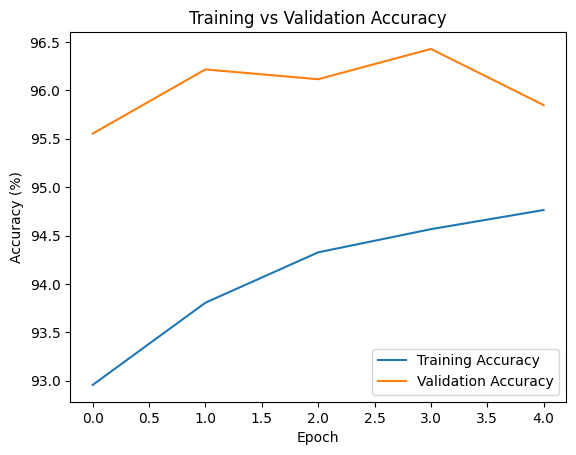

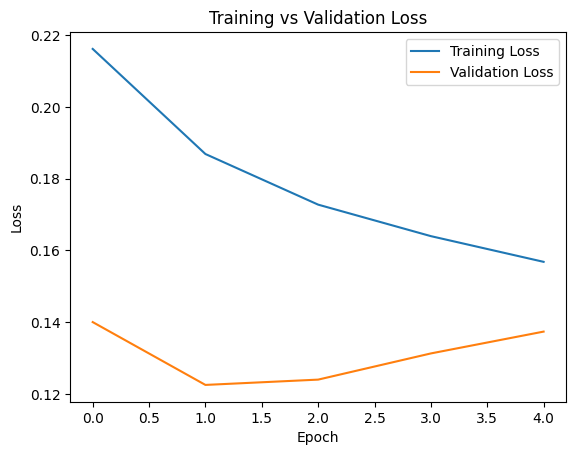

In [ ]:
import matplotlib.pyplot as plt
# Accuracy Graph
plt.figure()
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

# Loss Graph
plt.figure()
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [ ]:
CLASS_NAMES = [
    'Apple___Apple_scab','Apple___Black_rot','Apple___Cedar_apple_rust',
    'Apple___healthy','Blueberry___healthy',
    'Cherry_(including_sour)___Powdery_mildew','Cherry_(including_sour)___healthy',
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot','Corn_(maize)___Common_rust_',
    'Corn_(maize)___Northern_Leaf_Blight','Corn_(maize)___healthy',
    'Grape___Black_rot','Grape___Esca_(Black_Measles)',
    'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)','Grape___healthy',
    'Orange___Haunglongbing_(Citrus_greening)',
    'Peach___Bacterial_spot','Peach___healthy',
    'Pepper,_bell___Bacterial_spot','Pepper,_bell___healthy',
    'Potato___Early_blight','Potato___Late_blight','Potato___healthy',
    'Raspberry___healthy','Soybean___healthy','Squash___Powdery_mildew',
    'Strawberry___Leaf_scorch','Strawberry___healthy',
    'Tomato___Bacterial_spot','Tomato___Early_blight','Tomato___Late_blight','Tomato___Leaf_Mold',
    'Tomato___Septoria_leaf_spot','Tomato___Spider_mites Two-spotted_spider_mite',
    'Tomato___Target_Spot','Tomato___Tomato_mosaic_virus',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus','Tomato___healthy'
]
print(len(CLASS_NAMES))
len(set(all_labels))

38


38

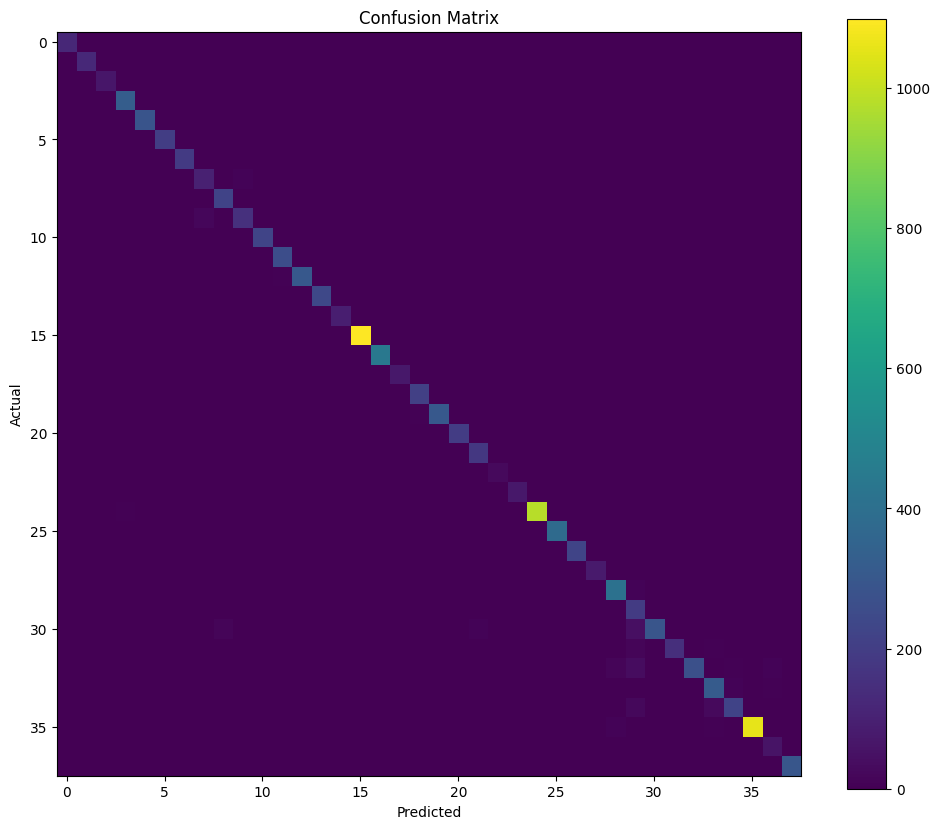

Accuracy: 95.85%

Classification Report:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.94      0.96       129
                                 Apple___Black_rot       0.98      1.00      0.99       128
                          Apple___Cedar_apple_rust       0.96      1.00      0.98        65
                                   Apple___healthy       0.94      0.99      0.96       325
                               Blueberry___healthy       1.00      0.98      0.99       292
          Cherry_(including_sour)___Powdery_mildew       0.99      0.97      0.98       204
                 Cherry_(including_sour)___healthy       0.99      1.00      0.99       185
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.81      0.90      0.85       111
                       Corn_(maize)___Common_rust_       0.94      1.00      0.97       220
               Corn_(maize)___Norther

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np
import matplotlib.pyplot as plt

model.eval()

all_preds = []
all_labels = []

# Collect predictions
with torch.no_grad():
    for images, labels in val_loader:
        images = images.cuda()
        labels = labels.cuda()

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# =============================
# 1. CONFUSION MATRIX
# =============================
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

# =============================
# 2. ACCURACY
# =============================
accuracy = accuracy_score(all_labels, all_preds)
print(f"Accuracy: {accuracy * 100:.2f}%")

# =============================
# 3. PRECISION, RECALL, F1
# =============================
report = classification_report(all_labels, all_preds, target_names=CLASS_NAMES)

print("\nClassification Report:\n")
print(report)

In [ ]:
MODEL_PATH = "densenet_plant_disease.pth"

torch.save(model.state_dict(), MODEL_PATH)

print("Model saved successfully!")


Model saved successfully!


In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
# Recreate model architecture
model = models.densenet121(pretrained=False)

num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, 38)

# Load trained weights
model.load_state_dict(torch.load("densenet_plant_disease.pth"))

# Move to GPU
model = model.cuda()
model.eval()

print("Model loaded and ready for inference")
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])
def predict_leaf_disease(image_path, model, class_names):

    image = Image.open(image_path).convert("RGB")
    image = inference_transform(image)
    image = image.unsqueeze(0).cuda()   # shape: [1, 3, 224, 224]

    with torch.no_grad():
        outputs = model(image)
        _, predicted = torch.max(outputs, 1)

    return class_names[predicted.item()]


Model loaded and ready for inference


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
MODEL_PATH = "/content/drive/MyDrive/densenet_plant_disease.pth"
torch.save(model.state_dict(), MODEL_PATH)

print("Model successfully saved to Google Drive!")


Mounted at /content/drive
Model successfully saved to Google Drive!


In [ ]:
image_path = "/content/leaf.JPG"   # change this
prediction = predict_leaf_disease(image_path, model, dataset.classes)

print("Predicted Disease:", prediction)


Predicted Disease: Grape___healthy
